In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import shap

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load dataset dari path
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\UMSU\Job Internal\Referensi Sinta 2 Bos Basir\smart_home_energy_consumption_large.csv")

# Parse datetime
df["Date"] = pd.to_datetime(df["Date"])
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M").dt.hour
df["Weekday"] = df["Date"].dt.weekday

# Sort time (CRITICAL)
df = df.sort_values(["Date", "Hour"], kind="stable").reset_index(drop=True)


In [4]:
target = "Energy Consumption (kWh)"

categorical_features = ["Appliance Type", "Season"]
numerical_features = [
    "Hour",
    "Weekday",
    "Outdoor Temperature (°C)",
    "Household Size"
]

X = df[categorical_features + numerical_features]
y = df[target]

In [5]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [7]:
X_train_sarimax = preprocessor.fit_transform(X_train)
X_test_sarimax = preprocessor.transform(X_test)

sarimax_model = SARIMAX(
    y_train,
    exog=X_train_sarimax,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)

y_pred_sarimax = sarimax_result.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test_sarimax
)


In [8]:
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)


In [9]:
xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)


In [10]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results = pd.DataFrame({
    "SARIMAX": evaluate(y_test, y_pred_sarimax),
    "Random Forest": evaluate(y_test, y_pred_rf),
    "XGBoost": evaluate(y_test, y_pred_xgb)
}).T

results


,MAE,RMSE,R2
SARIMAX,0.478373,0.587371,0.749376
Random Forest,0.486090,0.604294,0.734727
XGBoost,0.477925,0.588794,0.748160


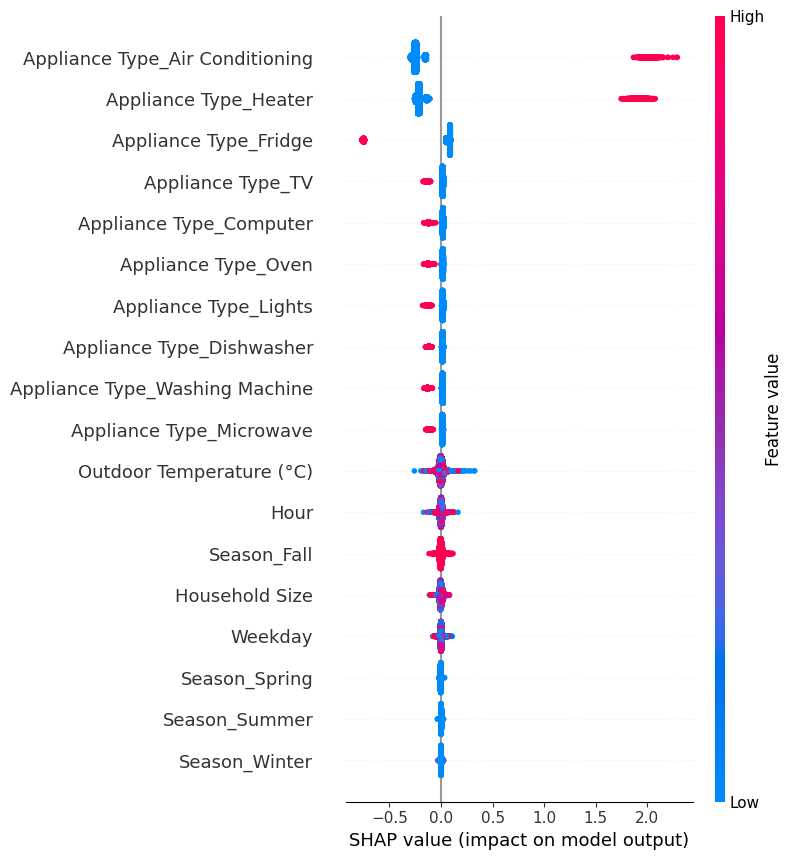

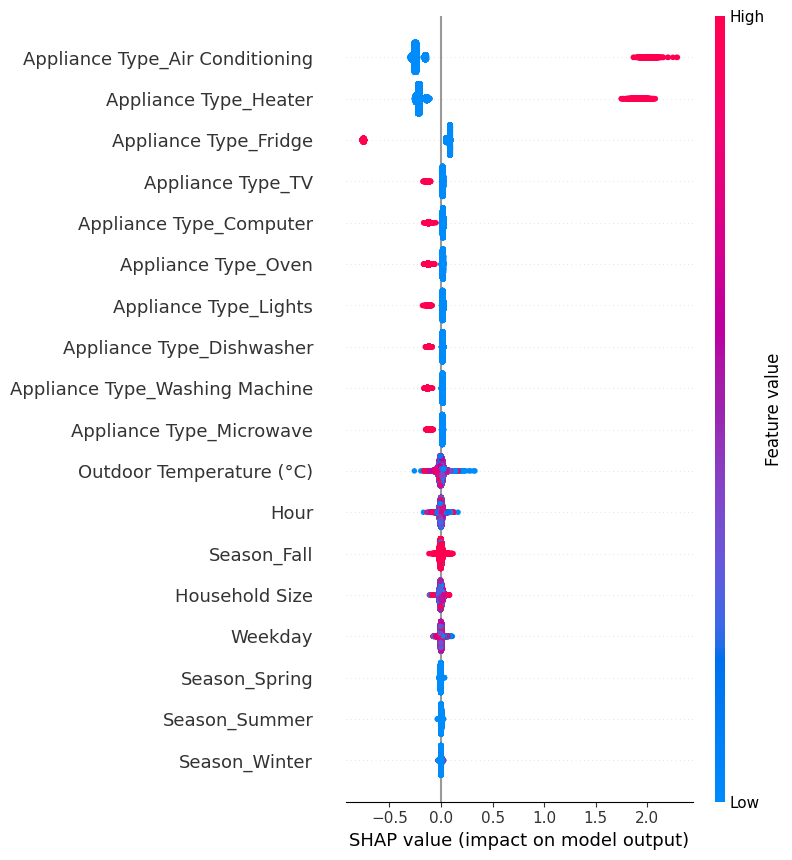

In [23]:
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

ohe = xgb_pipeline.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

feature_names = list(cat_feature_names) + numerical_features

X_test_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)
model = xgb_pipeline.named_steps["model"]

explainer = shap.TreeExplainer(model)

shap_values = explainer(X_test_df)

shap.summary_plot(
    shap_values,
    X_test_df,
    show=True
)

shap_values = explainer(X_test_df)
shap.summary_plot(
    shap_values,
    X_test_df,
    show=True
)

In [24]:
import matplotlib.pyplot as plt

def actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        linestyle="--"
    )
    plt.xlabel("Actual Energy Consumption (kWh)")
    plt.ylabel("Predicted Energy Consumption (kWh)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


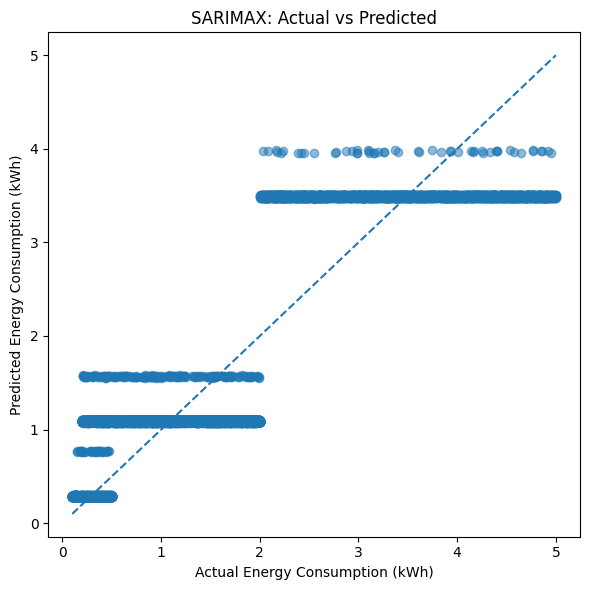

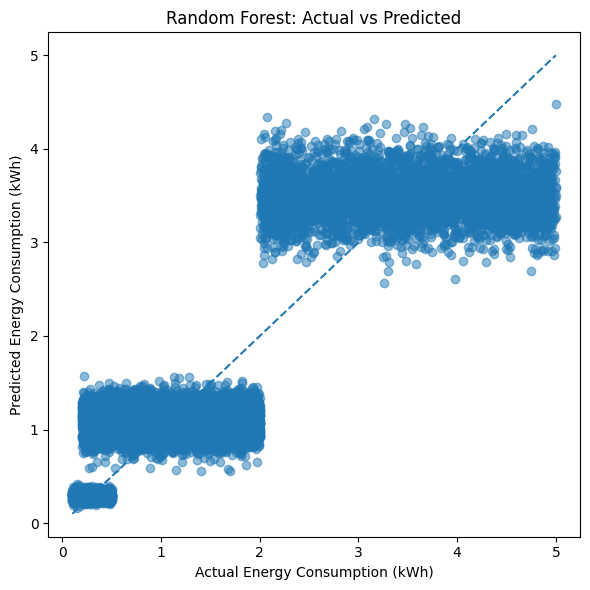

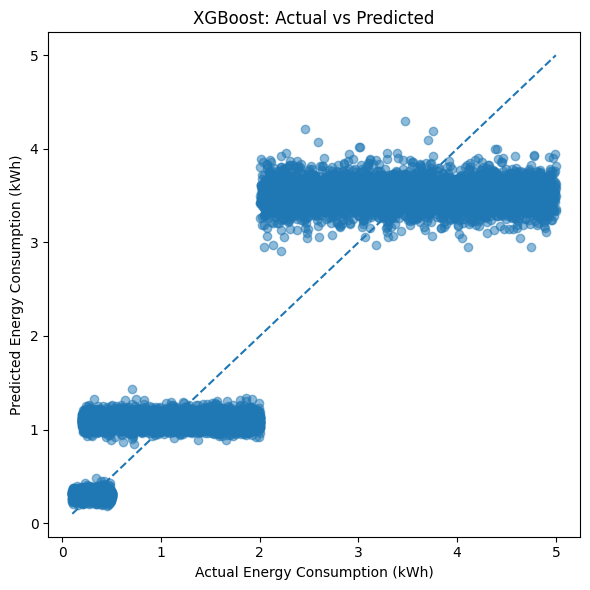

In [25]:
actual_vs_predicted(y_test, y_pred_sarimax, "SARIMAX: Actual vs Predicted")
actual_vs_predicted(y_test, y_pred_rf, "Random Forest: Actual vs Predicted")
actual_vs_predicted(y_test, y_pred_xgb, "XGBoost: Actual vs Predicted")


In [26]:
def error_distribution(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=40)
    plt.xlabel("Prediction Error (kWh)")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()


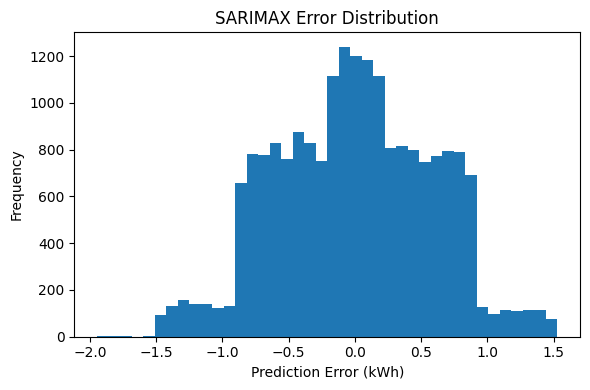

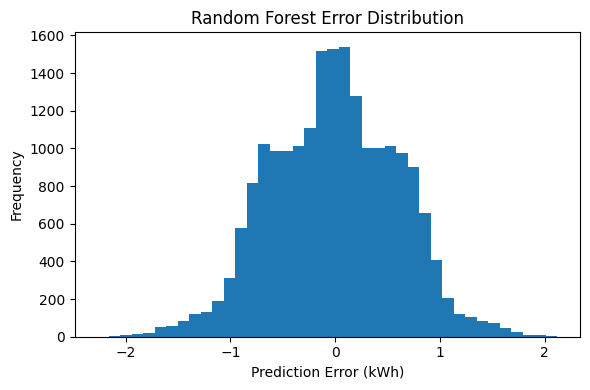

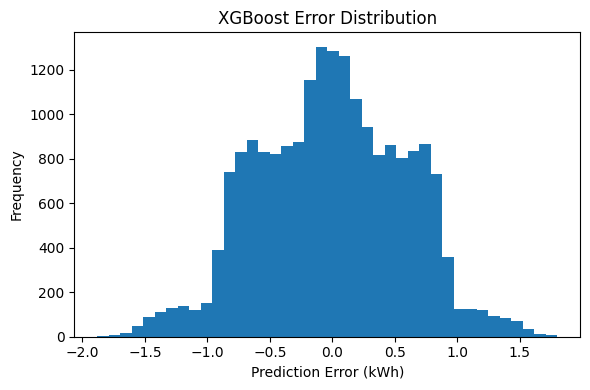

In [27]:
error_distribution(y_test, y_pred_sarimax, "SARIMAX Error Distribution")
error_distribution(y_test, y_pred_rf, "Random Forest Error Distribution")
error_distribution(y_test, y_pred_xgb, "XGBoost Error Distribution")


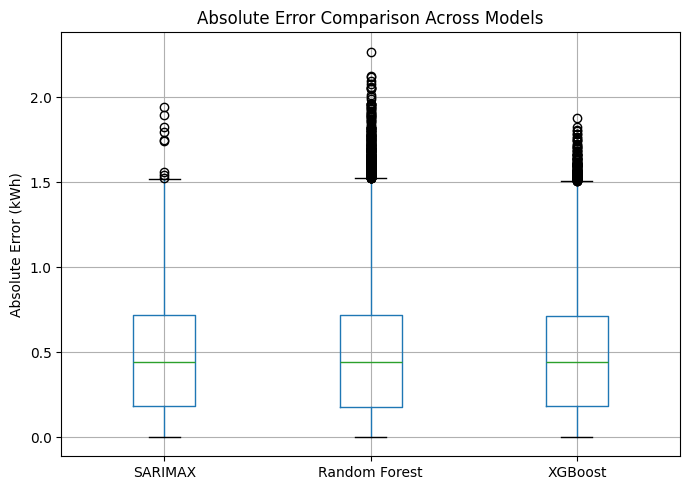

In [28]:
errors = pd.DataFrame({
    "SARIMAX": abs(y_test - y_pred_sarimax),
    "Random Forest": abs(y_test - y_pred_rf),
    "XGBoost": abs(y_test - y_pred_xgb)
})

plt.figure(figsize=(7,5))
errors.boxplot()
plt.ylabel("Absolute Error (kWh)")
plt.title("Absolute Error Comparison Across Models")
plt.tight_layout()
plt.show()


In [29]:
print(feature_names)



['Appliance Type_Air Conditioning', 'Appliance Type_Computer', 'Appliance Type_Dishwasher', 'Appliance Type_Fridge', 'Appliance Type_Heater', 'Appliance Type_Lights', 'Appliance Type_Microwave', 'Appliance Type_Oven', 'Appliance Type_TV', 'Appliance Type_Washing Machine', 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Hour', 'Weekday', 'Outdoor Temperature (°C)', 'Household Size']


In [30]:
# ============================================================
# SCRIPT 1: EKSPLORASI & VALIDASI DATASET
# Koreksi 2 - Sample Data & Statistik Deskriptif
# Jalankan ini pertama, catat output-nya
# ============================================================

import pandas as pd
import numpy as np

# ── LANGKAH 1: Load dataset ──────────────────────────────────
# Ganti path sesuai lokasi file CSV Anda
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\UMSU\Job Internal\Referensi Sinta 2 Bos Basir\smart_home_energy_consumption_large.csv")

# ── LANGKAH 2: Cek struktur dasar ───────────────────────────
print("=" * 60)
print("STRUKTUR DATASET")
print("=" * 60)
print(f"Jumlah baris (records)  : {len(df):,}")
print(f"Jumlah kolom (features) : {df.shape[1]}")
print(f"\nNama kolom:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. '{col}'  —  dtype: {df[col].dtype}")

# ── LANGKAH 3: Cek missing values ───────────────────────────
print("\n" + "=" * 60)
print("MISSING VALUES PER KOLOM")
print("=" * 60)
missing = df.isnull().sum()
for col, val in missing.items():
    status = "✅ OK" if val == 0 else f"⚠️  {val} missing"
    print(f"  {col:<35} : {status}")

# ── LANGKAH 4: Cek nilai unik kolom kategorik ────────────────
print("\n" + "=" * 60)
print("NILAI UNIK - KOLOM KATEGORIK")
print("=" * 60)
cat_cols = ["Appliance Type", "Season"]
for col in cat_cols:
    if col in df.columns:
        print(f"\n  [{col}] — {df[col].nunique()} nilai unik:")
        for val in sorted(df[col].unique()):
            count = df[col].value_counts()[val]
            pct = count / len(df) * 100
            print(f"    • {val:<20} : {count:>7,} records ({pct:.1f}%)")

# ── LANGKAH 5: Cek rentang nilai numerik ─────────────────────
print("\n" + "=" * 60)
print("RENTANG NILAI - KOLOM NUMERIK")
print("=" * 60)
num_cols = ["Household Size", "Outdoor Temperature (°C)", "Energy Consumption (kWh)"]
for col in num_cols:
    if col in df.columns:
        print(f"\n  [{col}]")
        print(f"    Min    : {df[col].min():.3f}")
        print(f"    Max    : {df[col].max():.3f}")
        print(f"    Mean   : {df[col].mean():.3f}")
        print(f"    Median : {df[col].median():.3f}")
        print(f"    Std    : {df[col].std():.3f}")

print("\n✅ Script 1 selesai. Catat output di atas, lalu jalankan Script 2.")

STRUKTUR DATASET
Jumlah baris (records)  : 100,000
Jumlah kolom (features) : 8

Nama kolom:
  1. 'Home ID'  —  dtype: int64
  2. 'Appliance Type'  —  dtype: object
  3. 'Energy Consumption (kWh)'  —  dtype: float64
  4. 'Time'  —  dtype: object
  5. 'Date'  —  dtype: object
  6. 'Outdoor Temperature (°C)'  —  dtype: float64
  7. 'Season'  —  dtype: object
  8. 'Household Size'  —  dtype: int64

MISSING VALUES PER KOLOM
  Home ID                             : ✅ OK
  Appliance Type                      : ✅ OK
  Energy Consumption (kWh)            : ✅ OK
  Time                                : ✅ OK
  Date                                : ✅ OK
  Outdoor Temperature (°C)            : ✅ OK
  Season                              : ✅ OK
  Household Size                      : ✅ OK

NILAI UNIK - KOLOM KATEGORIK

  [Appliance Type] — 10 nilai unik:
    • Air Conditioning     :  10,067 records (10.1%)
    • Computer             :   9,944 records (9.9%)
    • Dishwasher           :  10,095 records 

In [31]:
# ============================================================
# SCRIPT 2: EKSTRAK SAMPLE DATA & STATISTIK DESKRIPTIF
# Output script ini akan dimasukkan ke paper (Koreksi 2)
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\UMSU\Job Internal\Referensi Sinta 2 Bos Basir\smart_home_energy_consumption_large.csv")

# ── BAGIAN A: Sample Data Representatif ──────────────────────
# Strategi: ambil 1 contoh per Appliance Type agar representatif
# Ini lebih baik daripada random sample yang mungkin tidak variatif

print("=" * 70)
print("BAGIAN A: SAMPLE DATA REPRESENTATIF (untuk Table 2 di paper)")
print("=" * 70)

# Ambil 1 record per appliance type (pilih yang paling 'typical')
sample_rows = []
for appliance in sorted(df["Appliance Type"].unique()):
    subset = df[df["Appliance Type"] == appliance]
    # Ambil record dengan nilai kWh mendekati median appliance tersebut
    median_kwh = subset["Energy Consumption (kWh)"].median()
    closest_idx = (subset["Energy Consumption (kWh)"] - median_kwh).abs().idxmin()
    sample_rows.append(df.loc[closest_idx])

sample_df = pd.DataFrame(sample_rows).reset_index(drop=True)
sample_df.index = sample_df.index + 1  # mulai dari 1

print("\nSample records (1 per appliance type, nilai mendekati median):")
print(sample_df.to_string())

# ── BAGIAN B: Statistik Deskriptif Target Variable ───────────
print("\n" + "=" * 70)
print("BAGIAN B: STATISTIK DESKRIPTIF TARGET VARIABLE — kWh")
print("(untuk narasi Section 3.2 dan Footnote Table)")
print("=" * 70)

target = df["Energy Consumption (kWh)"]
stats = {
    "Count (records)"        : f"{len(target):,}",
    "Minimum (kWh)"          : f"{target.min():.4f}",
    "Maximum (kWh)"          : f"{target.max():.4f}",
    "Mean (kWh)"             : f"{target.mean():.4f}",
    "Median (kWh)"           : f"{target.median():.4f}",
    "Std Deviation (kWh)"    : f"{target.std():.4f}",
    "25th Percentile (kWh)"  : f"{target.quantile(0.25):.4f}",
    "75th Percentile (kWh)"  : f"{target.quantile(0.75):.4f}",
}
for k, v in stats.items():
    print(f"  {k:<30} : {v}")

# ── BAGIAN C: Statistik per Appliance Type ───────────────────
print("\n" + "=" * 70)
print("BAGIAN C: STATISTIK kWh PER APPLIANCE TYPE")
print("(untuk Table 3 di paper — statistik deskriptif dataset)")
print("=" * 70)

agg = df.groupby("Appliance Type")["Energy Consumption (kWh)"].agg(
    Count="count",
    Mean="mean",
    Std="std",
    Min="min",
    Median="median",
    Max="max"
).round(3)

agg["Count"] = agg["Count"].apply(lambda x: f"{x:,}")
print(agg.to_string())

# ── BAGIAN D: Distribusi per Season ─────────────────────────
print("\n" + "=" * 70)
print("BAGIAN D: DISTRIBUSI RECORDS PER SEASON")
print("=" * 70)

season_dist = df.groupby("Season").agg(
    Records=("Energy Consumption (kWh)", "count"),
    Mean_kWh=("Energy Consumption (kWh)", "mean")
).round(3)
season_dist["Records"] = season_dist["Records"].apply(lambda x: f"{x:,}")
print(season_dist.to_string())

# ── BAGIAN E: Split Info ──────────────────────────────────────
print("\n" + "=" * 70)
print("BAGIAN E: INFORMASI TRAIN/TEST SPLIT")
print("=" * 70)
total = len(df)
train_size = int(total * 0.8)
test_size  = total - train_size
print(f"  Total records  : {total:,}")
print(f"  Training set   : {train_size:,} records (80%)")
print(f"  Test set       : {test_size:,}  records (20%)")
print(f"  Split method   : Time-based (chronological order)")

print("\n✅ Script 2 selesai. Copy semua output di atas dan kirim ke saya.")
print("   Saya akan gunakan angka-angka ini untuk menulis Section 3.2 yang akurat.")

BAGIAN A: SAMPLE DATA REPRESENTATIF (untuk Table 2 di paper)

Sample records (1 per appliance type, nilai mendekati median):
    Home ID    Appliance Type  Energy Consumption (kWh)   Time        Date  Outdoor Temperature (°C)  Season  Household Size
1       273  Air Conditioning                      3.49  17:30  2023-07-11                      29.8  Summer               1
2       483          Computer                      1.09  20:37  2023-01-24                      35.6  Winter               2
3       418        Dishwasher                      1.10  20:45  2023-12-15                      -1.0    Fall               1
4       133            Fridge                      0.30  12:30  2023-10-25                      16.2    Fall               5
5       138            Heater                      3.48  13:53  2023-05-29                      13.4  Spring               3
6       456            Lights                      1.08  04:42  2023-10-11                      38.4    Fall               3


In [32]:

# ============================================================

import pandas as pd
import numpy as np

# ── LANGKAH 1: Gabungkan actual + predicted + fitur konteks ──
full_results = pd.DataFrame({
    'Appliance_Type' : X_test['Appliance Type'].values,
    'Season'         : X_test['Season'].values,
    'Temp_C'         : X_test['Outdoor Temperature (°C)'].values,
    'Household_Size' : X_test['Household Size'].values,
    'Actual_kWh'     : np.array(y_test).flatten(),
    'SARIMAX_Pred'   : np.array(y_pred_sarimax).flatten(),
    'RF_Pred'        : np.array(y_pred_rf).flatten(),
    'XGB_Pred'       : np.array(y_pred_xgb).flatten(),
})

# Round semua nilai prediksi
for col in ['Actual_kWh','SARIMAX_Pred','RF_Pred','XGB_Pred']:
    full_results[col] = full_results[col].round(3)

# ── LANGKAH 2: Tambahkan error per model ─────────────────────
full_results['Err_SARIMAX'] = (full_results['Actual_kWh'] - full_results['SARIMAX_Pred']).round(3)
full_results['Err_RF']      = (full_results['Actual_kWh'] - full_results['RF_Pred']).round(3)
full_results['Err_XGB']     = (full_results['Actual_kWh'] - full_results['XGB_Pred']).round(3)

# ── LANGKAH 3: Buat consumption regime ───────────────────────
full_results['Regime'] = pd.cut(
    full_results['Actual_kWh'],
    bins  = [0, 0.5, 1.5, 2.5, 3.5, 5.1],
    labels= ['Very Low (0.0–0.5 kWh)',
             'Low (0.5–1.5 kWh)',
             'Medium (1.5–2.5 kWh)',
             'High (2.5–3.5 kWh)',
             'Very High (3.5–5.0 kWh)']
)

# ── LANGKAH 4: Stratified sample — 3 per regime ──────────────
print("=" * 75)
print("OUTPUT A: DISTRIBUSI TEST SET PER CONSUMPTION REGIME")
print("=" * 75)
dist = full_results['Regime'].value_counts().sort_index()
for regime, count in dist.items():
    pct = count / len(full_results) * 100
    print(f"  {regime:<28} : {count:>6,} records ({pct:.1f}%)")

sampled = (full_results
           .groupby('Regime', observed=True)
           .apply(lambda x: x.sample(n=min(3, len(x)), random_state=42))
           .reset_index(drop=True))
sampled.index = sampled.index + 1

print("\n" + "=" * 75)
print("OUTPUT B: 15 SAMPLE RECORDS (3 per regime) — UNTUK TABLE DI PAPER")
print("=" * 75)
display_cols = ['Regime','Appliance_Type','Season','Temp_C',
                'Actual_kWh','SARIMAX_Pred','RF_Pred','XGB_Pred',
                'Err_SARIMAX','Err_RF','Err_XGB']
print(sampled[display_cols].to_string())

# ── LANGKAH 5: MAE per regime ─────────────────────────────────
print("\n" + "=" * 75)
print("OUTPUT C: MAE PER CONSUMPTION REGIME (ANALISIS REGIME-SPECIFIC)")
print("=" * 75)
regime_mae = full_results.groupby('Regime', observed=True).agg(
    n_records   = ('Actual_kWh',   'count'),
    Mean_Actual = ('Actual_kWh',   'mean'),
    MAE_SARIMAX = ('Err_SARIMAX',  lambda x: x.abs().mean()),
    MAE_RF      = ('Err_RF',       lambda x: x.abs().mean()),
    MAE_XGB     = ('Err_XGB',      lambda x: x.abs().mean()),
).round(4)
regime_mae['n_records'] = regime_mae['n_records'].apply(lambda x: f"{x:,}")
print(regime_mae.to_string())

# ── LANGKAH 6: MAE per appliance type ────────────────────────
print("\n" + "=" * 75)
print("OUTPUT D: MAE PER APPLIANCE TYPE — UNTUK ANALISIS MENDALAM")
print("=" * 75)
appliance_mae = full_results.groupby('Appliance_Type').agg(
    n         = ('Actual_kWh',  'count'),
    MAE_SARIMAX = ('Err_SARIMAX', lambda x: x.abs().mean()),
    MAE_RF      = ('Err_RF',      lambda x: x.abs().mean()),
    MAE_XGB     = ('Err_XGB',     lambda x: x.abs().mean()),
).round(4)
appliance_mae['n'] = appliance_mae['n'].apply(lambda x: f"{x:,}")
print(appliance_mae.to_string())

print("\n✅ Script 3 selesai! Copy SEMUA output A, B, C, D dan kirim ke saya.")

OUTPUT A: DISTRIBUSI TEST SET PER CONSUMPTION REGIME
  Very Low (0.0–0.5 kWh)       :  4,373 records (21.9%)
  Low (0.5–1.5 kWh)            :  7,739 records (38.7%)
  Medium (1.5–2.5 kWh)         :  4,586 records (22.9%)
  High (2.5–3.5 kWh)           :  1,366 records (6.8%)
  Very High (3.5–5.0 kWh)      :  1,936 records (9.7%)

OUTPUT B: 15 SAMPLE RECORDS (3 per regime) — UNTUK TABLE DI PAPER
                     Regime    Appliance_Type Season  Temp_C  Actual_kWh  SARIMAX_Pred  RF_Pred  XGB_Pred  Err_SARIMAX  Err_RF  Err_XGB
1    Very Low (0.0–0.5 kWh)            Fridge   Fall    33.3        0.11         0.289    0.270     0.275       -0.179  -0.160   -0.165
2    Very Low (0.0–0.5 kWh)              Oven   Fall    26.6        0.45         1.094    1.085     1.087       -0.644  -0.635   -0.637
3    Very Low (0.0–0.5 kWh)            Fridge   Fall     6.7        0.48         0.289    0.333     0.285        0.191   0.147    0.195
4         Low (0.5–1.5 kWh)   Washing Machine   Fall    25

In [22]:
import sys, sklearn, statsmodels, xgboost, shap, scipy
from scipy import stats

# --- Versi software (isi ke naskah) ---
print("Python", sys.version.split()[0])
for m in (np, pd, sklearn, xgboost, shap, statsmodels, scipy):
    print(m.__name__, m.__version__)

# --- SMAPE + tabel metrik lengkap (untuk Tabel 7) ---
def smape(y, p):
    y, p = np.asarray(y), np.asarray(p)
    return np.mean(np.abs(y - p) / ((np.abs(y) + np.abs(p)) / 2)) * 100

y = np.asarray(y_test).ravel()
preds = {"SARIMAX": np.asarray(y_pred_sarimax).ravel(),
         "Random Forest": np.asarray(y_pred_rf).ravel(),
         "XGBoost": np.asarray(y_pred_xgb).ravel()}

table7 = pd.DataFrame({k: {**evaluate(y, p), "SMAPE (%)": smape(y, p)}
                       for k, p in preds.items()}).T.round(4)
print(table7)

# --- Uji statistik berpasangan: XGBoost vs baseline ---
rng = np.random.default_rng(42)
n, B = len(y), 2000
idx = rng.integers(0, n, size=(B, n))

def boot_ci(p_base, p_new):
    dMAE, dRMSE, dR2 = [], [], []
    for i in idx:
        yt, a, b = y[i], p_base[i], p_new[i]
        dMAE.append(np.mean(np.abs(yt - a)) - np.mean(np.abs(yt - b)))
        dRMSE.append(np.sqrt(np.mean((yt - a)**2)) - np.sqrt(np.mean((yt - b)**2)))
        dR2.append(r2_score(yt, b) - r2_score(yt, a))
    q = lambda v: np.percentile(v, [2.5, 97.5]).round(4)
    return {"dMAE": q(dMAE), "dRMSE": q(dRMSE), "dR2": q(dR2)}

for name in ["Random Forest", "SARIMAX"]:
    p = preds[name]
    w = stats.wilcoxon(np.abs(y - p), np.abs(y - preds["XGBoost"]))
    print(f"\nXGBoost vs {name}")
    print("  95% CI (baseline - XGB; R2: XGB - baseline):", boot_ci(p, preds["XGBoost"]))
    print("  Wilcoxon p-value (absolute error):", w.pvalue)

Python 3.10.0
numpy 1.24.3
pandas 2.1.1
sklearn 1.3.2
xgboost 2.1.4
shap 0.49.1
statsmodels 0.14.2
scipy 1.14.1
                  MAE    RMSE      R2  SMAPE (%)
SARIMAX        0.4784  0.5874  0.7494    39.5428
Random Forest  0.4861  0.6043  0.7347    39.9742
XGBoost        0.4779  0.5888  0.7482    39.4581

XGBoost vs Random Forest
  95% CI (baseline - XGB; R2: XGB - baseline): {'dMAE': array([0.0065, 0.01  ]), 'dRMSE': array([0.0133, 0.0177]), 'dR2': array([0.0115, 0.0154])}
  Wilcoxon p-value (absolute error): 9.814581711498469e-17

XGBoost vs SARIMAX
  95% CI (baseline - XGB; R2: XGB - baseline): {'dMAE': array([-0.0008,  0.0017]), 'dRMSE': array([-0.003 ,  0.0002]), 'dR2': array([-0.0026,  0.0002])}
  Wilcoxon p-value (absolute error): 0.11579491809099918


In [33]:
pd.DataFrame({
    "y_test": np.asarray(y_test).ravel(),
    "SARIMAX": np.asarray(y_pred_sarimax).ravel(),
    "RF": np.asarray(y_pred_rf).ravel(),
    "XGBoost": np.asarray(y_pred_xgb).ravel(),
}).to_csv("predictions_test.csv", index=False)

In [34]:
from scipy.stats import skew

# (a) Baseline naif: rata-rata train per Appliance Type
train_mu = y_train.groupby(X_train["Appliance Type"]).mean()
p_naive = X_test["Appliance Type"].map(train_mu).values
print("Naive baseline:", {k: round(v, 4) for k, v in evaluate(y, p_naive).items()},
      "SMAPE", round(smape(y, p_naive), 2))

# (b) Distribusi Season & rentang tanggal pada train/test
print(X_test["Season"].value_counts(normalize=True).round(3))
print("Train:", df["Date"].iloc[:split_index].min(), "→", df["Date"].iloc[:split_index].max())
print("Test :", df["Date"].iloc[split_index:].min(), "→", df["Date"].iloc[split_index:].max())

# (c) Statistik residual (menggantikan pengamatan visual Gambar 7-10)
for k, p in preds.items():
    r = y - p
    ae = np.abs(r)
    print(k, f"bias={r.mean():.4f} skew={skew(r):.3f} "
          f"P5={np.percentile(r,5):.3f} P95={np.percentile(r,95):.3f} "
          f"medAE={np.median(ae):.3f} IQR_AE={np.percentile(ae,[25,75]).round(3)}")

Naive baseline: {'MAE': 0.476, 'RMSE': 0.5844, 'R2': 0.7519} SMAPE 39.31
Season
Fall      0.986
Winter    0.014
Name: proportion, dtype: float64
Train: 2023-01-01 → 2024-01-01
Test : 2023-01-01 → 2024-01-01
SARIMAX bias=-0.0046 skew=-0.030 P5=-0.884 P95=0.880 medAE=0.440 IQR_AE=[0.18  0.715]
Random Forest bias=-0.0062 skew=-0.022 P5=-0.948 P95=0.931 medAE=0.439 IQR_AE=[0.179 0.716]
XGBoost bias=-0.0067 skew=-0.031 P5=-0.899 P95=0.885 medAE=0.438 IQR_AE=[0.182 0.711]


In [36]:
# (1) Cek tanggal yang benar (data diurutkan ulang, TIDAK memakai df yang ter-overwrite)
PATH = r"C:\Users\Lenovo\OneDrive\UMSU\Job Internal\Referensi Sinta 2 Bos Basir\smart_home_energy_consumption_large.csv"   # isi path CSV
d = pd.read_csv(PATH)
d["Date"] = pd.to_datetime(d["Date"])
d["Hour"] = pd.to_datetime(d["Time"], format="%H:%M").dt.hour
d = d.sort_values(["Date", "Hour"], kind="stable").reset_index(drop=True)
tr, te = d.iloc[:split_index], d.iloc[split_index:]
print("Train:", tr["Date"].min().date(), "→", tr["Date"].max().date())
print("Test :", te["Date"].min().date(), "→", te["Date"].max().date())
print("Season train:\n", tr["Season"].value_counts(normalize=True).round(3))
print("Season test:\n", te["Season"].value_counts(normalize=True).round(3))
print("Konsisten dgn X_test:", (te["Season"].values == X_test["Season"].values).all())

from scipy.stats import wilcoxon

# (2) Wilcoxon: XGBoost vs baseline naif
print("Wilcoxon p (XGB vs Naive):",
      wilcoxon(np.abs(y - p_naive), np.abs(y - preds["XGBoost"])).pvalue)

# (3) Kepentingan SHAP per fitur asli (one-hot digabung)
def orig(f):
    for c in categorical_features:
        if f.startswith(c + "_"):
            return c
    return f
sv = pd.DataFrame(shap_values.values, columns=feature_names)
grouped = sv.T.groupby(orig).sum().T
print(grouped.abs().mean().sort_values(ascending=False).round(4))

# (4) Apakah fitur lain punya sinyal di luar rata-rata appliance?
chk = X_test.copy()
chk["res"] = y - p_naive
for c in ["Hour", "Weekday", "Household Size"]:
    m = chk.groupby(c)["res"].mean()
    print(c, "range rata-rata residual:", round(m.max() - m.min(), 3))
m = chk.groupby(pd.cut(chk["Outdoor Temperature (°C)"], 8), observed=True)["res"].mean()
print("Temp range rata-rata residual:", round(m.max() - m.min(), 3))

Train: 2023-01-01 → 2023-10-19
Test : 2023-10-19 → 2024-01-01
Season train:
 Season
Spring    0.314
Summer    0.312
Winter    0.308
Fall      0.066
Name: proportion, dtype: float64
Season test:
 Season
Fall      0.986
Winter    0.014
Name: proportion, dtype: float64
Konsisten dgn X_test: True
Wilcoxon p (XGB vs Naive): 0.0028041571415147143
Appliance Type              0.8076
Outdoor Temperature (°C)    0.0191
Season                      0.0126
Hour                        0.0119
Household Size              0.0108
Weekday                     0.0078
dtype: float32
Hour range rata-rata residual: 0.092
Weekday range rata-rata residual: 0.028
Household Size range rata-rata residual: 0.037
Temp range rata-rata residual: 0.022


Fridge             -1.201
TV                 -0.413
Lights             -0.407
Washing Machine    -0.405
Oven               -0.404
Computer           -0.403
Dishwasher         -0.398
Microwave          -0.396
Heater              1.990
Air Conditioning    2.020
Name: Appliance Type, dtype: float32
Expected value: 1.5007847547531128


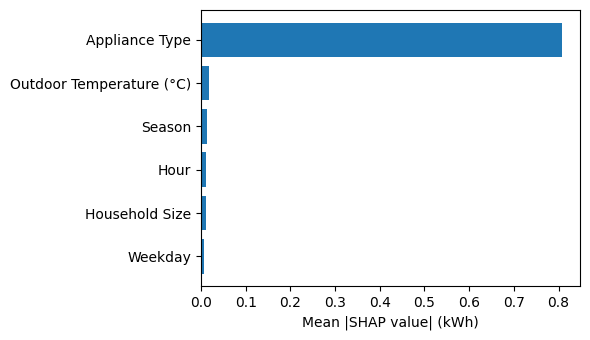

In [37]:
# (A) Rata-rata kontribusi SHAP per jenis appliance (isi placeholder)
ap_shap = grouped["Appliance Type"].groupby(X_test["Appliance Type"].values).mean().sort_values()
print(ap_shap.round(3))
print("Expected value:", float(np.ravel(shap_values.base_values)[0]))

# (B) Gambar 3 baru: bar chart kepentingan per fitur asli
import matplotlib.pyplot as plt
imp = grouped.abs().mean().sort_values()
plt.figure(figsize=(6, 3.5))
plt.barh(imp.index, imp.values)
plt.xlabel("Mean |SHAP value| (kWh)")
plt.tight_layout()
plt.savefig("fig3_shap_importance.png", dpi=300)
plt.show()

# (C) Beeswarm lama dijalankan ulang bila ingin dipakai sebagai gambar pendukung
shap.summary_plot(shap_values, X_test_df, show=False)
plt.tight_layout(); plt.savefig("fig3b_shap_beeswarm.png", dpi=300); plt.close()